In [139]:
%load_ext autoreload
%autoreload 2

from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD
import time
import numpy as np
import matplotlib.pyplot as plt


LOG.propagate = False

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [137]:
# Set up Connection

ble = get_ble_controller()
ble.connect()

2026-02-09 21:15:42,189 | INFO     |: Looking for Artemis Nano Peripheral Device: c0:81:c0:26:ac:64
2026-02-09 21:15:42,190 | INFO     |: Scanning for device with address: c0:81:c0:26:ac:64, service UUID: 290dc602-9e54-4179-9433-fa61bb0b4b95
2026-02-09 21:15:52,244 | INFO     |: Found 1 device(s) advertising service 290dc602-9e54-4179-9433-fa61bb0b4b95
2026-02-09 21:15:52,246 | INFO     |: Selecting device: D582A51D-6B46-854A-7124-A24895E2EA03 (name: Artemis BLE)
2026-02-09 21:15:53,081 | INFO     |: Connected to c0:81:c0:26:ac:64


In [132]:
ble.stop_notify(ble.uuid['RX_STRING'])

In [44]:


filename = "fast_imu.csv"

def notification_handler(sender_uuid, data):

    datapoint = data.decode("utf-8").strip()
    parts = datapoint.split(",")
    time = parts[0]          
    accel_roll = parts[1]     
    accel_pitch = parts[2]
    lpf_roll = parts[3]
    lpf_pitch = parts[4]
    gyro_roll = parts[5]
    gyro_pitch = parts[6]
    gyro_yaw = parts[7]
    cf_roll = parts[8]
    cf_pitch = parts[9]
    
    with open(filename, "a+") as f:
            f.seek(0)
            if f.read(1) == "":
                f.write("Time,AccelRoll,AccelPitch,LPFRoll,LPFPitch,GyroRoll,GyroPitch,GyroYaw,CFRoll,CFPitch\n")
            f.write(f"{time},{accel_roll},{accel_pitch},{lpf_roll},{lpf_pitch},{gyro_roll},{gyro_pitch},{gyro_yaw},{cf_roll},{cf_pitch}\n")
    
        
ble.start_notify(ble.uuid['RX_STRING'], notification_handler)
ble.send_command(CMD.GET_IMU_DATA, "")


Sampling period: 0.011003 seconds
Sampling frequency: 90.88 Hz
Number of samples: 300
Total sampling time: 3.289999999999999


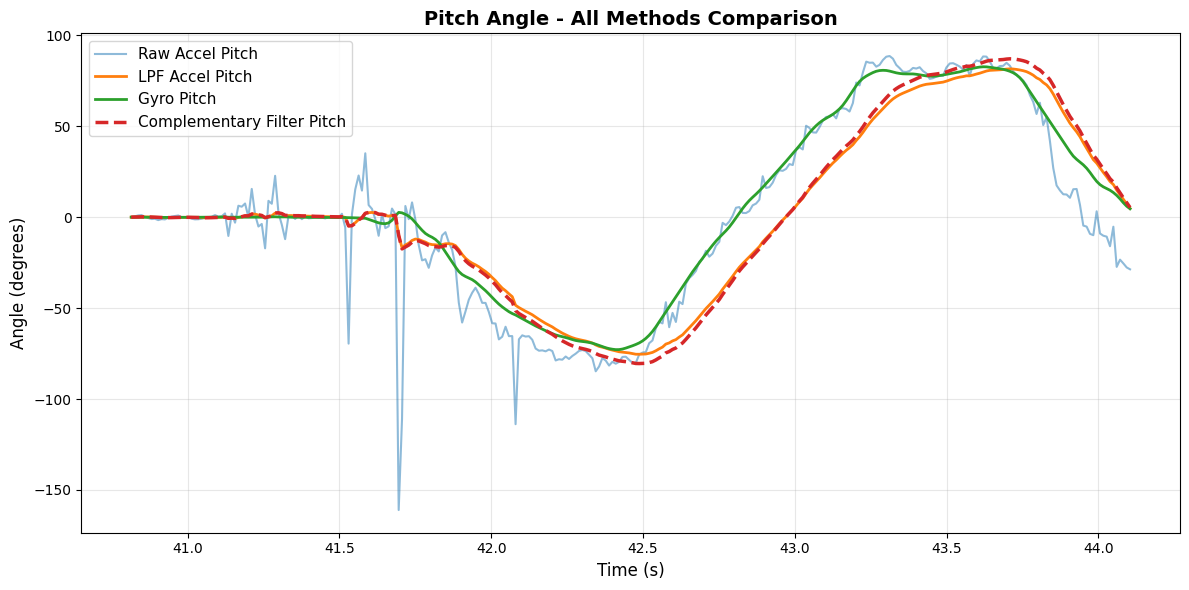

In [30]:
# Plot accelerometer pitch, lpf pitch, gyro pitch, cf pitch

# Load data
data = np.loadtxt(filename, delimiter=',', skiprows=1)
time = data[:, 0] / 1000  # Convert ms to seconds
accel_pitch = data[:, 2]
lpf_pitch = data[:, 4]
gyro_pitch = data[:, 6]
cf_pitch = data[:, 9]

# Calculate sampling info
N = len(time)
T = np.mean(np.diff(time))
fs = 1 / T
total_t = time[-1] - time[0]
print(f"Sampling period: {T:.6f} seconds")
print(f"Sampling frequency: {fs:.2f} Hz")
print(f"Number of samples: {N}")
print(f"Total sampling time: {total_t}")

# Create single plot for pitch comparison
plt.figure(figsize=(12, 6))
plt.plot(time, accel_pitch, label='Raw Accel Pitch', alpha=0.5, linewidth=1.5)
plt.plot(time, lpf_pitch, label='LPF Accel Pitch', linewidth=2)
plt.plot(time, gyro_pitch, label='Gyro Pitch', linewidth=2)
plt.plot(time, cf_pitch, label='Complementary Filter Pitch', linewidth=2.5, linestyle='--')

plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Angle (degrees)', fontsize=12)
plt.title('Pitch Angle - All Methods Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pitch_comparison.png', dpi=300)
plt.show()


Sampling period: 0.011000 seconds
Sampling frequency: 90.91 Hz
Number of samples: 300
Total sampling time: 3.2890000000000015


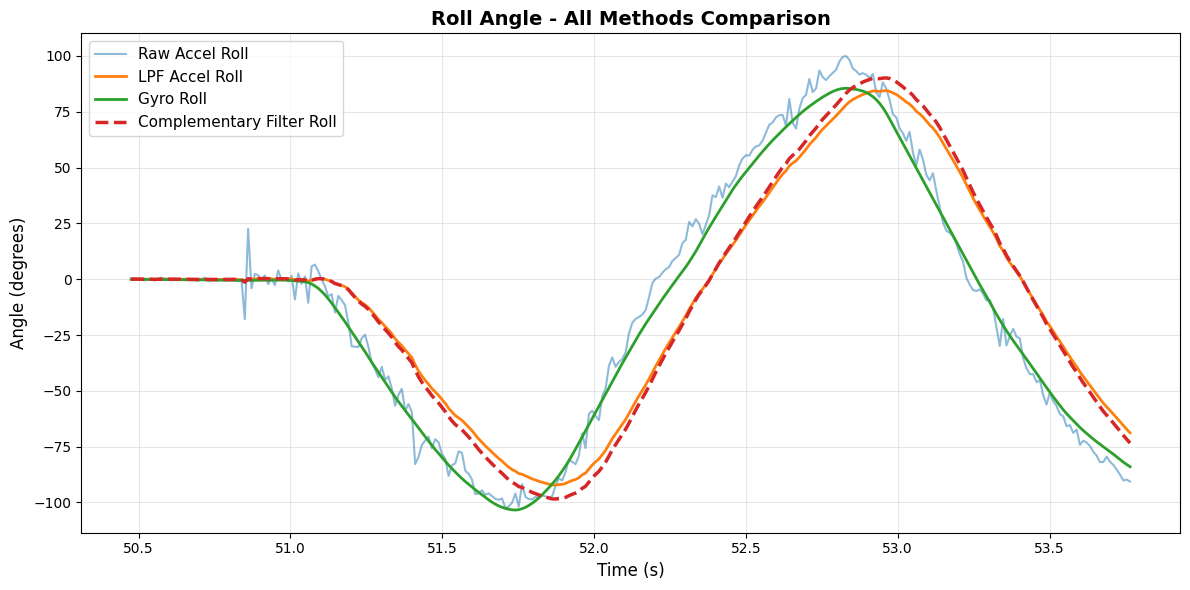

In [37]:
# Plot accelerometer roll, lpf roll, gyro roll, cf roll

# Load data
data = np.loadtxt(filename, delimiter=',', skiprows=1)
time = data[:, 0] / 1000  # Convert ms to seconds
accel_roll = data[:, 1]
lpf_roll = data[:, 3]
gyro_roll = data[:, 5]
cf_roll = data[:, 8]

# Calculate sampling info
N = len(time)
T = np.mean(np.diff(time))
fs = 1 / T
total_t = time[-1] - time[0]
print(f"Sampling period: {T:.6f} seconds")
print(f"Sampling frequency: {fs:.2f} Hz")
print(f"Number of samples: {N}")
print(f"Total sampling time: {total_t}")

# Create single plot for roll comparison
plt.figure(figsize=(12, 6))
plt.plot(time, accel_roll, label='Raw Accel Roll', alpha=0.5, linewidth=1.5)
plt.plot(time, lpf_roll, label='LPF Accel Roll', linewidth=2)
plt.plot(time, gyro_roll, label='Gyro Roll', linewidth=2)
plt.plot(time, cf_roll, label='Complementary Filter Roll', linewidth=2.5, linestyle='--')

plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Angle (degrees)', fontsize=12)
plt.title('Roll Angle - All Methods Comparison', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roll_comparison.png', dpi=300)
plt.show()

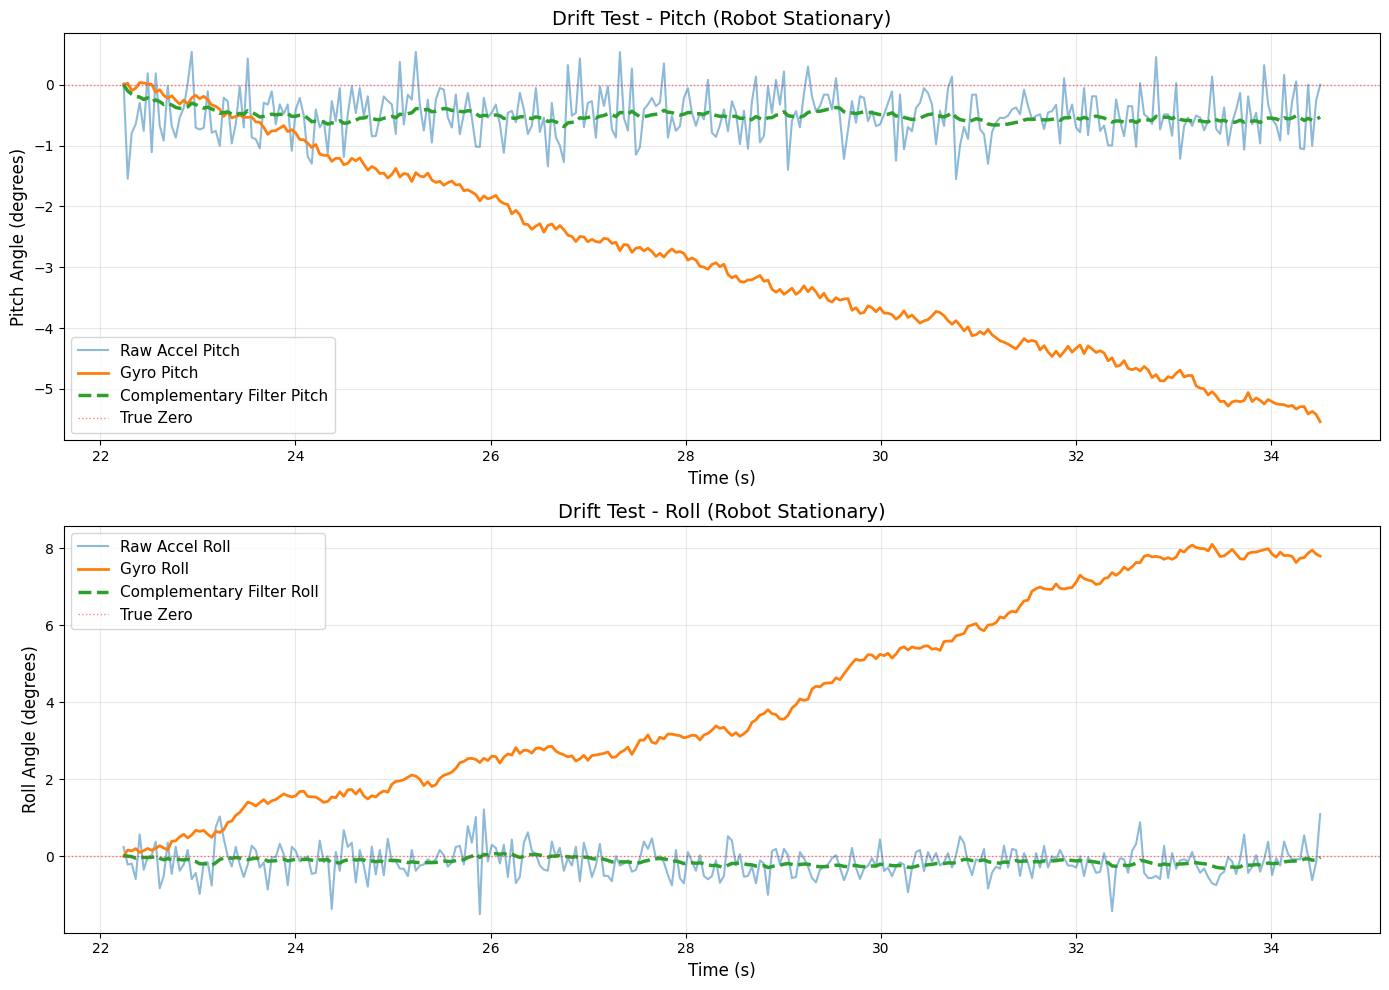

DRIFT ANALYSIS - ROBOT STATIONARY
Test duration: 34.5 seconds
Number of samples: 300

------------------------------------------------------------
PITCH ANALYSIS:
------------------------------------------------------------
Gyroscope drift:          -5.54° (BAD if |drift| > 5°)
CF drift:                 -0.53° (GOOD if |drift| < 1°)
Accelerometer noise (σ):  0.39°
CF noise (σ):             0.09°
Noise reduction:          76.3%

------------------------------------------------------------
ROLL ANALYSIS:
------------------------------------------------------------
Gyroscope drift:          +7.79° (BAD if |drift| > 5°)
CF drift:                 -0.04° (GOOD if |drift| < 1°)
Accelerometer noise (σ):  0.39°
CF noise (σ):             0.09°
Noise reduction:          78.3%

SUMMARY:
✅ CF shows minimal drift - PASS
✅ CF reduces noise effectively - PASS


In [42]:
import numpy as np
import matplotlib.pyplot as plt

# Load data from stationary test
data = np.loadtxt('drift_data.csv', delimiter=',', skiprows=1)
time = data[:, 0] / 1000

# Pitch data
accel_pitch = data[:, 2]
gyro_pitch = data[:, 6]
cf_pitch = data[:, 9]

# Roll data
accel_roll = data[:, 1]
gyro_roll = data[:, 5]
cf_roll = data[:, 8]

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# ========== PITCH PLOT ==========
ax1.plot(time, accel_pitch, label='Raw Accel Pitch', alpha=0.5, linewidth=1.5)
ax1.plot(time, gyro_pitch, label='Gyro Pitch', linewidth=2)
ax1.plot(time, cf_pitch, label='Complementary Filter Pitch', linewidth=2.5, linestyle='--')
ax1.axhline(y=0, color='red', linestyle=':', linewidth=1, alpha=0.5, label='True Zero')

ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Pitch Angle (degrees)', fontsize=12)
ax1.set_title('Drift Test - Pitch (Robot Stationary)', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# ========== ROLL PLOT ==========
ax2.plot(time, accel_roll, label='Raw Accel Roll', alpha=0.5, linewidth=1.5)
ax2.plot(time, gyro_roll, label='Gyro Roll', linewidth=2)
ax2.plot(time, cf_roll, label='Complementary Filter Roll', linewidth=2.5, linestyle='--')
ax2.axhline(y=0, color='red', linestyle=':', linewidth=1, alpha=0.5, label='True Zero')

ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_ylabel('Roll Angle (degrees)', fontsize=12)
ax2.set_title('Drift Test - Roll (Robot Stationary)', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('drift_test_pitch_roll.png', dpi=300)
plt.show()

# ========== DRIFT ANALYSIS ==========
# Pitch metrics
gyro_pitch_drift = gyro_pitch[-1] - gyro_pitch[0]
cf_pitch_drift = cf_pitch[-1] - cf_pitch[0]
accel_pitch_noise = np.std(accel_pitch)
cf_pitch_noise = np.std(cf_pitch)

# Roll metrics
gyro_roll_drift = gyro_roll[-1] - gyro_roll[0]
cf_roll_drift = cf_roll[-1] - cf_roll[0]
accel_roll_noise = np.std(accel_roll)
cf_roll_noise = np.std(cf_roll)

print("=" * 60)
print("DRIFT ANALYSIS - ROBOT STATIONARY")
print("=" * 60)
print(f"Test duration: {time[-1]:.1f} seconds")
print(f"Number of samples: {len(time)}")
print()
print("-" * 60)
print("PITCH ANALYSIS:")
print("-" * 60)
print(f"Gyroscope drift:          {gyro_pitch_drift:+.2f}° (BAD if |drift| > 5°)")
print(f"CF drift:                 {cf_pitch_drift:+.2f}° (GOOD if |drift| < 1°)")
print(f"Accelerometer noise (σ):  {accel_pitch_noise:.2f}°")
print(f"CF noise (σ):             {cf_pitch_noise:.2f}°")
print(f"Noise reduction:          {(1 - cf_pitch_noise/accel_pitch_noise)*100:.1f}%")
print()
print("-" * 60)
print("ROLL ANALYSIS:")
print("-" * 60)
print(f"Gyroscope drift:          {gyro_roll_drift:+.2f}° (BAD if |drift| > 5°)")
print(f"CF drift:                 {cf_roll_drift:+.2f}° (GOOD if |drift| < 1°)")
print(f"Accelerometer noise (σ):  {accel_roll_noise:.2f}°")
print(f"CF noise (σ):             {cf_roll_noise:.2f}°")
print(f"Noise reduction:          {(1 - cf_roll_noise/accel_roll_noise)*100:.1f}%")
print()
print("=" * 60)
print("SUMMARY:")
print("=" * 60)
if abs(cf_pitch_drift) < 1.0 and abs(cf_roll_drift) < 1.0:
    print("✅ CF shows minimal drift - PASS")
else:
    print("❌ CF shows significant drift - FAIL")
    
if cf_pitch_noise < accel_pitch_noise * 0.5 and cf_roll_noise < accel_roll_noise * 0.5:
    print("✅ CF reduces noise effectively - PASS")
else:
    print("⚠️  CF noise reduction could be better")
print("=" * 60)

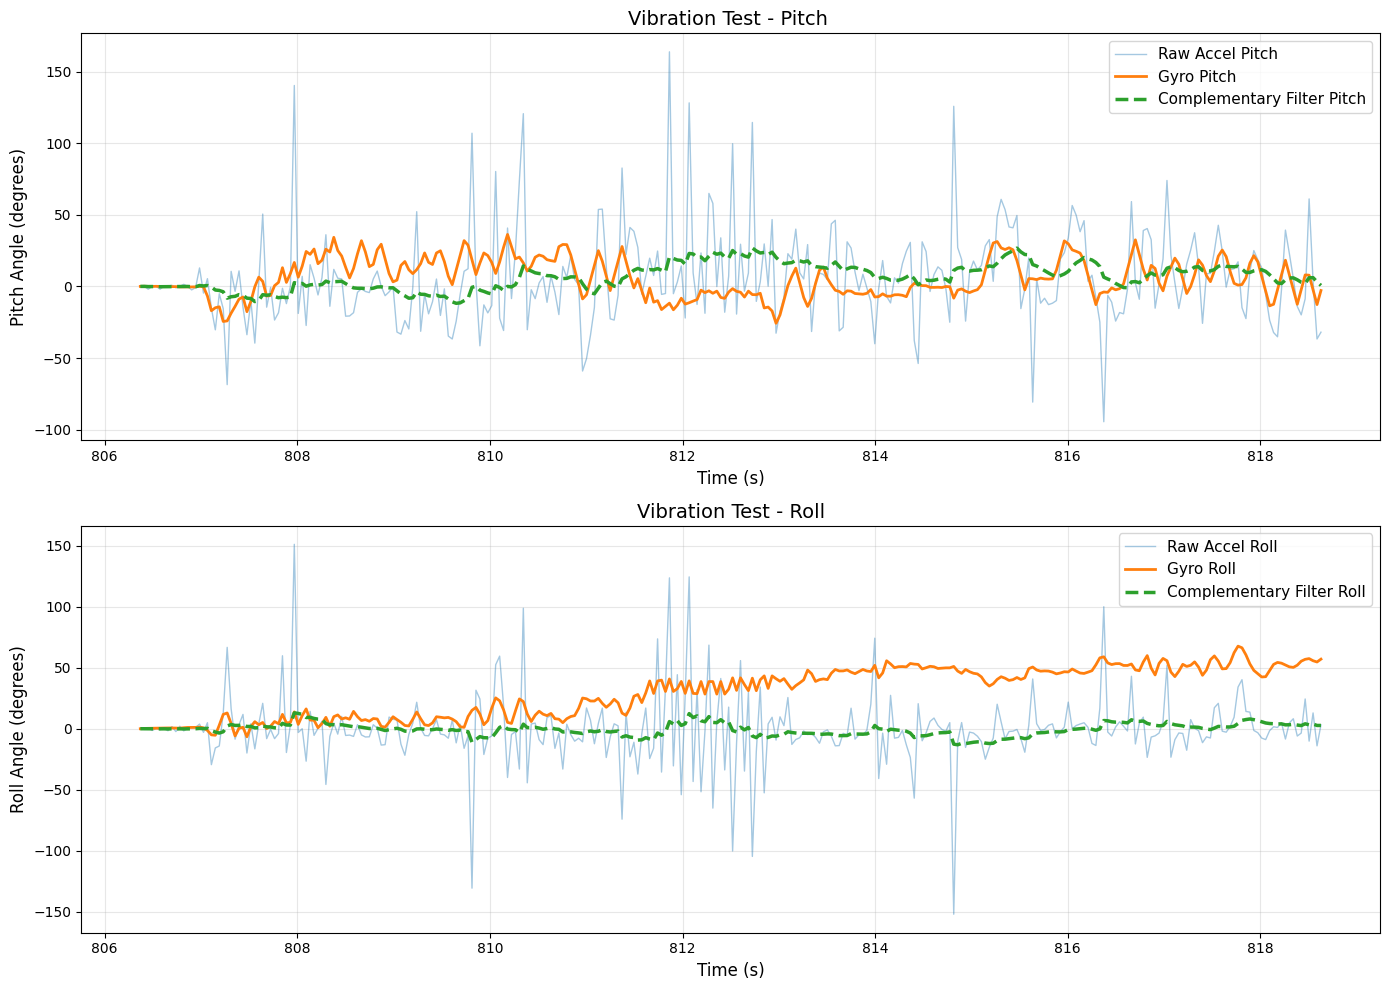

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Load vibration test data
data = np.loadtxt('vibration_data.csv', delimiter=',', skiprows=1)
time = data[:, 0] / 1000

# Pitch data
accel_pitch = data[:, 2]
gyro_pitch = data[:, 6]
cf_pitch = data[:, 9]

# Roll data
accel_roll = data[:, 1]
gyro_roll = data[:, 5]
cf_roll = data[:, 8]

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# ========== PITCH PLOT ==========
ax1.plot(time, accel_pitch, label='Raw Accel Pitch', alpha=0.4, linewidth=1)
ax1.plot(time, gyro_pitch, label='Gyro Pitch', linewidth=2)
ax1.plot(time, cf_pitch, label='Complementary Filter Pitch', linewidth=2.5, linestyle='--')

ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Pitch Angle (degrees)', fontsize=12)
ax1.set_title('Vibration Test - Pitch ', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# ========== ROLL PLOT ==========
ax2.plot(time, accel_roll, label='Raw Accel Roll', alpha=0.4, linewidth=1)
ax2.plot(time, gyro_roll, label='Gyro Roll', linewidth=2)
ax2.plot(time, cf_roll, label='Complementary Filter Roll', linewidth=2.5, linestyle='--')

ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_ylabel('Roll Angle (degrees)', fontsize=12)
ax2.set_title('Vibration Test - Roll', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('vibration_test_pitch_roll.png', dpi=300)
plt.show()

# ========== NOISE ANALYSIS ==========
# Pitch metrics
accel_pitch_std = np.std(accel_pitch)
gyro_pitch_std = np.std(gyro_pitch)
cf_pitch_std = np.std(cf_pitch)
accel_pitch_range = np.max(accel_pitch) - np.min(accel_pitch)
cf_pitch_range = np.max(cf_pitch) - np.min(cf_pitch)

# Roll metrics
accel_roll_std = np.std(accel_roll)
gyro_roll_std = np.std(gyro_roll)
cf_roll_std = np.std(cf_roll)
accel_roll_range = np.max(accel_roll) - np.min(accel_roll)
cf_roll_range = np.max(cf_roll) - np.min(cf_roll)


In [140]:
print("start")
ble.send_command(CMD.START_IMU_COLLECTION,"")
time.sleep(7)
print("end")
ble.send_command(CMD.STOP_IMU_COLLECTION,"")

filename = "fast_imu.csv"

def notification_handler(sender_uuid, data):

    datapoint = data.decode("utf-8").strip()
    parts = datapoint.split(",")
    time = parts[0]          
    accel_roll = parts[1]     
    accel_pitch = parts[2]
    lpf_roll = parts[3]
    lpf_pitch = parts[4]
    gyro_roll = parts[5]
    gyro_pitch = parts[6]
    gyro_yaw = parts[7]
    cf_roll = parts[8]
    cf_pitch = parts[9]
    
    with open(filename, "a+") as f:
            f.seek(0)
            if f.read(1) == "":
                f.write("Time,AccelRoll,AccelPitch,LPFRoll,LPFPitch,GyroRoll,GyroPitch,GyroYaw,CFRoll,CFPitch\n")
            f.write(f"{time},{accel_roll},{accel_pitch},{lpf_roll},{lpf_pitch},{gyro_roll},{gyro_pitch},{gyro_yaw},{cf_roll},{cf_pitch}\n")
    
        
ble.start_notify(ble.uuid['RX_STRING'], notification_handler)
ble.send_command(CMD.SEND_COLLECTED_IMU_DATA, "")



start
end


TIME ANALYSIS
Total sampling time:        7.030 seconds
Number of samples:          2190
Mean time difference (dt):  0.003212 seconds (3.212 ms)
Std dev of dt:              0.001975 seconds (1.975 ms)
Min time difference:        0.002000 seconds (2.000 ms)
Max time difference:        0.008000 seconds (8.000 ms)
Sampling frequency:         311.38 Hz


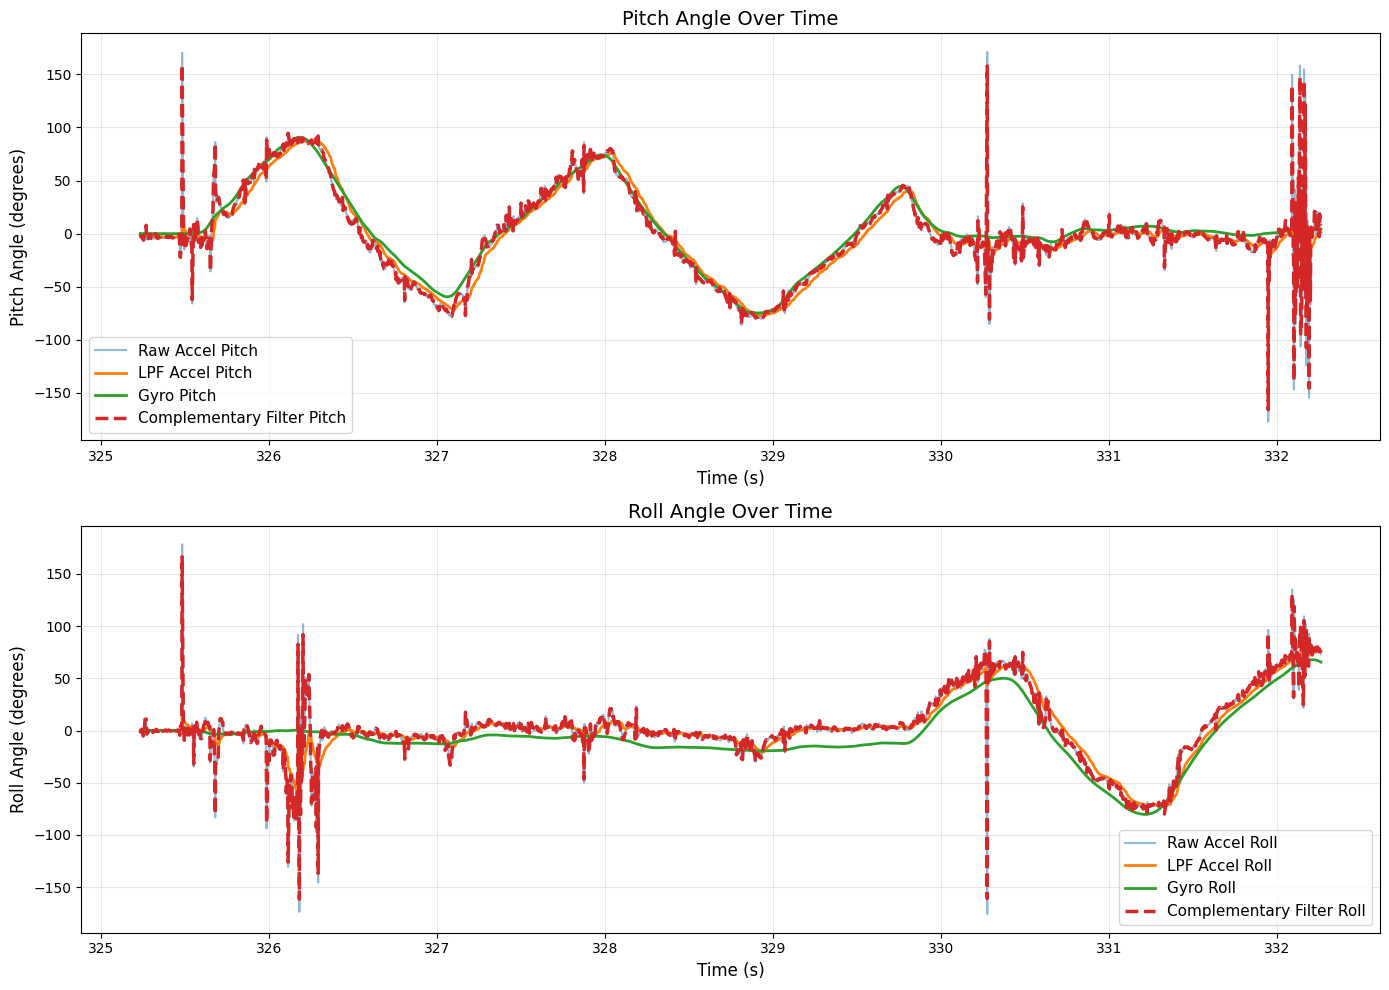

In [136]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
data = np.loadtxt('fast_imu.csv', delimiter=',', skiprows=1)
time = data[:, 0] / 1000  # Convert ms to seconds

# Pitch data
accel_pitch = data[:, 2]
lpf_pitch = data[:, 4]
gyro_pitch = data[:, 6]
cf_pitch = data[:, 9]

# Roll data
accel_roll = data[:, 1]
lpf_roll = data[:, 3]
gyro_roll = data[:, 5]
cf_roll = data[:, 8]

# Calculate time differences
time_diffs = np.diff(time)
mean_dt = np.mean(time_diffs)
std_dt = np.std(time_diffs)
min_dt = np.min(time_diffs)
max_dt = np.max(time_diffs)
total_time = time[-1] - time[0]

# Print time analysis
print("=" * 60)
print("TIME ANALYSIS")
print("=" * 60)
print(f"Total sampling time:        {total_time:.3f} seconds")
print(f"Number of samples:          {len(time)}")
print(f"Mean time difference (dt):  {mean_dt:.6f} seconds ({mean_dt*1000:.3f} ms)")
print(f"Std dev of dt:              {std_dt:.6f} seconds ({std_dt*1000:.3f} ms)")
print(f"Min time difference:        {min_dt:.6f} seconds ({min_dt*1000:.3f} ms)")
print(f"Max time difference:        {max_dt:.6f} seconds ({max_dt*1000:.3f} ms)")
print(f"Sampling frequency:         {1/mean_dt:.2f} Hz")
print("=" * 60)

# Create figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# ========== PITCH PLOT ==========
ax1.plot(time, accel_pitch, label='Raw Accel Pitch', alpha=0.5, linewidth=1.5)
ax1.plot(time, lpf_pitch, label='LPF Accel Pitch', linewidth=2)
ax1.plot(time, gyro_pitch, label='Gyro Pitch', linewidth=2)
ax1.plot(time, cf_pitch, label='Complementary Filter Pitch', linewidth=2.5, linestyle='--')

ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Pitch Angle (degrees)', fontsize=12)
ax1.set_title('Pitch Angle Over Time', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# ========== ROLL PLOT ==========
ax2.plot(time, accel_roll, label='Raw Accel Roll', alpha=0.5, linewidth=1.5)
ax2.plot(time, lpf_roll, label='LPF Accel Roll', linewidth=2)
ax2.plot(time, gyro_roll, label='Gyro Roll', linewidth=2)
ax2.plot(time, cf_roll, label='Complementary Filter Roll', linewidth=2.5, linestyle='--')

ax2.set_xlabel('Time (s)', fontsize=12)
ax2.set_ylabel('Roll Angle (degrees)', fontsize=12)
ax2.set_title('Roll Angle Over Time', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('pitch_roll_over_time.png', dpi=300)
plt.show()

In [130]:
ble.send_command(CMD.GET_TOTAL_LOOPS,"")